In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


**DATA UNDERSTANDING**

In [2]:
df1 = pd.read_excel("Raw Data.xlsx", sheet_name='orders')
df2 = pd.read_excel("Raw Data.xlsx", sheet_name='customers')
df3 = pd.read_excel("Raw Data.xlsx", sheet_name='products')

In [3]:
df1.info()
#1000 row
#8 columns all nulls


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       1000 non-null   object        
 1   Order Date     1000 non-null   datetime64[ns]
 2   Customer ID    1000 non-null   object        
 3   Product ID     1000 non-null   object        
 4   Quantity       1000 non-null   int64         
 5   Customer Name  0 non-null      float64       
 6   Email          0 non-null      float64       
 7   Country        0 non-null      float64       
 8   Coffee Type    0 non-null      float64       
 9   Roast Type     0 non-null      float64       
 10  Size           0 non-null      float64       
 11  Unit Price     0 non-null      float64       
 12  Sales          0 non-null      float64       
dtypes: datetime64[ns](1), float64(8), int64(1), object(3)
memory usage: 101.7+ KB


In [4]:
df1 = df1.dropna(axis=1)
#dropping null columns

In [5]:
df2.info()
#nulls found in phone number & email
#data types are ok

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer ID     1000 non-null   object
 1   Customer Name   1000 non-null   object
 2   Email           796 non-null    object
 3   Phone Number    870 non-null    object
 4   Address Line 1  1000 non-null   object
 5   City            1000 non-null   object
 6   Country         1000 non-null   object
 7   Postcode        1000 non-null   object
 8   Loyalty Card    1000 non-null   object
dtypes: object(9)
memory usage: 70.4+ KB


In [6]:
df3.info()
#no nulls
#data types are ok

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Product ID      48 non-null     object 
 1   Coffee Type     48 non-null     object 
 2   Roast Type      48 non-null     object 
 3   Size            48 non-null     float64
 4   Unit Price      48 non-null     float64
 5   Price per 100g  48 non-null     float64
 6   Profit          48 non-null     float64
dtypes: float64(4), object(3)
memory usage: 2.8+ KB


 **How many rows and columns does each file have?**
 - Orders File: 1000 Row & 13 Columns --> 8 columns were nulls so we dropped them
 - Customer File: 1000 Row & 9 Columns
 - Products File: 48 Row & 7 Columns


**What does each column represent?**

Orders Worksheet:
- Order ID: A unique identifier for each coffee order.
- Order Date: The date when the order was placed.
- Customer ID: An identifier linking the order to a specific customer.
- Product ID: A unique identifier for each coffee product.
- Quantity: The quantity of the coffee product ordered.

Customers Worksheet:
- Customer ID: A unique identifier for each customer.
- Customer Name: The name of the customer.
- Email Address: Contact information for customers.
- Phone Number: Another contact detail for customers.
- Address Line 1 : Customer address
- City: Customer city
- Country: Customer
- Postcode: Postcode of the city where customer lives
- Loyality Card: whethet customer have loyality card or not

Products Worksheet:
- Product ID: A unique identifier for each coffee product.
- Coffee Type: The type or blend of coffee, such as Arabica or Robusta.
- Roast Type: The roast level, including light, medium, or dark roast.
- Size: Information about the product size.
- Unit Price: The price of a single unit of the coffee product.
- Price Per 100g: The price per 100 grams for detailed price comparisons.
- Profit: Insights into the profitability of each coffee product.

**Which columns are used to connect the three files?**

- orders and customers ---> on Customer ID
- orders and products ----> on Product ID


**What are your first impressions of the data's quality?**

- Completeness:
    - there is NaNs in email and phone number in the customer worksheet
    - there is an eight all Nans columns (Custommer name , Email , Country , Coffee Type , Roast Type , Size , Unit Price Sales) in the orders worksheets
- Validity
    - all the data types are Ok


In [7]:
df_ord_cust = df1.merge(df2,how="left", on="Customer ID")

In [8]:
df = df_ord_cust.merge(df3, how='left', on='Product ID')
df.head()

,Order ID,Order Date,Customer ID,Product ID,Quantity,Customer Name,Email,Phone Number,Address Line 1,City,Country,Postcode,Loyalty Card,Coffee Type,Roast Type,Size,Unit Price,Price per 100g,Profit
0,QEV-37451-860,2019-09-05,17670-51384-MA,R-M-1,2,Aloisia Allner,aallner0@lulu.com,+1 (862) 817-0124,57999 Pepper Wood Alley,Paterson,United States,7505,Yes,Rob,M,1.0,9.950,0.9950,0.5970
1,QEV-37451-860,2019-09-05,17670-51384-MA,E-M-0.5,5,Aloisia Allner,aallner0@lulu.com,+1 (862) 817-0124,57999 Pepper Wood Alley,Paterson,United States,7505,Yes,Exc,M,0.5,8.250,1.6500,0.9075
2,FAA-43335-268,2021-06-17,21125-22134-PX,A-L-1,1,Jami Redholes,jredholes2@tmall.com,+1 (210) 986-6806,5214 Bartillon Park,San Antonio,United States,78205,Yes,Ara,L,1.0,12.950,1.2950,1.1655
3,KAC-83089-793,2021-07-15,23806-46781-OU,E-M-1,2,Christoffer O' Shea,NaN,+353 (698) 362-9201,38980 Manitowish Junction,Cill Airne,Ireland,N41,No,Exc,M,1.0,13.750,1.3750,1.5125
4,KAC-83089-793,2021-07-15,23806-46781-OU,R-L-2.5,2,Christoffer O' Shea,NaN,+353 (698) 362-9201,38980 Manitowish Junction,Cill Airne,Ireland,N41,No,Rob,L,2.5,27.485,1.0994,1.6491


**Data Quality Report**

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1000 non-null   object        
 1   Order Date      1000 non-null   datetime64[ns]
 2   Customer ID     1000 non-null   object        
 3   Product ID      1000 non-null   object        
 4   Quantity        1000 non-null   int64         
 5   Customer Name   1000 non-null   object        
 6   Email           794 non-null    object        
 7   Phone Number    865 non-null    object        
 8   Address Line 1  1000 non-null   object        
 9   City            1000 non-null   object        
 10  Country         1000 non-null   object        
 11  Postcode        1000 non-null   object        
 12  Loyalty Card    1000 non-null   object        
 13  Coffee Type     1000 non-null   object        
 14  Roast Type      1000 non-null   object        
 15  Size 

In [10]:
df.isna().sum()

Order ID            0
Order Date          0
Customer ID         0
Product ID          0
Quantity            0
Customer Name       0
Email             206
Phone Number      135
Address Line 1      0
City                0
Country             0
Postcode            0
Loyalty Card        0
Coffee Type         0
Roast Type          0
Size                0
Unit Price          0
Price per 100g      0
Profit              0
dtype: int64

In [11]:
email = round((df["Email"].isna().sum()/df.shape[0])*100, 2)
phone = round((df["Phone Number"].isna().sum()/df.shape[0])*100, 2)
print(f"Email Null Percentage: {email}%\nPhone Number Null Percentage: {phone}%")

Email Null Percentage: 20.6%
Phone Number Null Percentage: 13.5%


In [12]:
df.duplicated().sum()
#no duplicates found

np.int64(0)

In [13]:
df.dtypes
#all columns are in the correct data type

Order ID                  object
Order Date        datetime64[ns]
Customer ID               object
Product ID                object
Quantity                   int64
Customer Name             object
Email                     object
Phone Number              object
Address Line 1            object
City                      object
Country                   object
Postcode                  object
Loyalty Card              object
Coffee Type               object
Roast Type                object
Size                     float64
Unit Price               float64
Price per 100g           float64
Profit                   float64
dtype: object

In [14]:
cat_df =  df.select_dtypes(include='object')
cat_df.head()
#categorical data frame

,Order ID,Customer ID,Product ID,Customer Name,Email,Phone Number,Address Line 1,City,Country,Postcode,Loyalty Card,Coffee Type,Roast Type
0,QEV-37451-860,17670-51384-MA,R-M-1,Aloisia Allner,aallner0@lulu.com,+1 (862) 817-0124,57999 Pepper Wood Alley,Paterson,United States,7505,Yes,Rob,M
1,QEV-37451-860,17670-51384-MA,E-M-0.5,Aloisia Allner,aallner0@lulu.com,+1 (862) 817-0124,57999 Pepper Wood Alley,Paterson,United States,7505,Yes,Exc,M
2,FAA-43335-268,21125-22134-PX,A-L-1,Jami Redholes,jredholes2@tmall.com,+1 (210) 986-6806,5214 Bartillon Park,San Antonio,United States,78205,Yes,Ara,L
3,KAC-83089-793,23806-46781-OU,E-M-1,Christoffer O' Shea,NaN,+353 (698) 362-9201,38980 Manitowish Junction,Cill Airne,Ireland,N41,No,Exc,M
4,KAC-83089-793,23806-46781-OU,R-L-2.5,Christoffer O' Shea,NaN,+353 (698) 362-9201,38980 Manitowish Junction,Cill Airne,Ireland,N41,No,Rob,L


In [15]:
for col in cat_df:
    print(cat_df[col].value_counts())
#Country, Coffee Type, Roast Type --> are consistent

Order ID
NOP-21394-646    5
PKN-19556-918    4
NCH-55389-562    4
CTE-31437-326    4
TKL-20738-660    3
                ..
LTN-89139-350    1
IRX-59256-644    1
POF-29666-012    1
HKN-31467-517    1
FDO-25756-141    1
Name: count, Length: 957, dtype: int64
Customer ID
86579-92122-OC    7
66458-91190-YC    5
16982-35708-BZ    5
94091-86957-HX    5
16880-78077-FB    4
                 ..
77869-81373-AY    1
38536-98293-JZ    1
43014-53743-XK    1
64965-78386-MY    1
57611-05522-ST    1
Name: count, Length: 913, dtype: int64
Product ID
A-M-0.5    30
A-M-1      28
A-M-2.5    27
A-D-0.2    27
R-D-0.2    26
R-L-0.2    26
L-D-0.5    26
L-L-0.2    25
L-M-0.2    24
E-D-0.5    24
R-M-0.5    24
E-M-1      23
A-L-2.5    23
A-D-0.5    23
R-L-1      23
L-D-2.5    23
E-L-0.5    23
E-M-2.5    23
R-D-2.5    22
E-M-0.5    21
E-L-1      21
L-L-0.5    21
L-L-1      21
A-D-2.5    20
R-L-2.5    20
L-D-1      20
E-D-2.5    20
L-L-2.5    20
L-M-0.5    20
A-L-0.5    20
E-D-0.2    20
E-L-0.2    19
E-D-1      18

In [16]:
df['City'].value_counts()

City
Washington       26
New York City    17
Oklahoma City    15
Houston          15
Birmingham       13
                 ..
Silver Spring     1
Conroe            1
Bundoran          1
Daytona Beach     1
Wirral            1
Name: count, Length: 375, dtype: int64

In [17]:
for col in cat_df:
    has_spaces = df[col].str.contains(r'^\s+|\s+$', regex=True, na=False)
    count = has_spaces.sum()
    print(f'{col}: has {count} spaces')
#no spaces found

Order ID: has 0 spaces
Customer ID: has 0 spaces
Product ID: has 0 spaces
Customer Name: has 0 spaces
Email: has 0 spaces
Phone Number: has 0 spaces
Address Line 1: has 0 spaces
City: has 0 spaces
Country: has 0 spaces
Postcode: has 0 spaces
Loyalty Card: has 0 spaces
Coffee Type: has 0 spaces
Roast Type: has 0 spaces


In [18]:
for col in cat_df:
    col_unique = df[col].nunique()
    lower_unique = df[col].str.lower().nunique() 
    if col_unique > lower_unique:
       print(f"Column {col} has mixed capitalization") 
    

Column Postcode has mixed capitalization


In [19]:
cities = df['City'].unique()

In [20]:
from thefuzz import process
for value in cities:
    matches = process.extract(value, cities, limit=5)
    close_matches = [m for m in matches if 90 <= m[1] < 100]
    if close_matches:
        print(f"{value}  -->  Matches: {close_matches}")

Dayton  -->  Matches: [('Daytona Beach', 90)]
Kill  -->  Matches: [('Killorglin', 90), ('Shankill', 90)]
Hartford  -->  Matches: [('West Hartford', 90), ('Ford', 90)]
Washington  -->  Matches: [('Port Washington', 90)]
Charlotte  -->  Matches: [('Charlottesville', 90)]
Port Washington  -->  Matches: [('Washington', 90)]
Huntington  -->  Matches: [('Huntington Beach', 90)]
Killorglin  -->  Matches: [('Kill', 90)]
Stamford  -->  Matches: [('Ford', 90)]
Ashford  -->  Matches: [('Ford', 90)]
Charlottesville  -->  Matches: [('Charlotte', 90)]
Denton  -->  Matches: [('Bradenton', 90)]
Shankill  -->  Matches: [('Kill', 90)]
Miami Beach  -->  Matches: [('Miami', 90)]
Eaton  -->  Matches: [('Seaton', 91)]
West Hartford  -->  Matches: [('Hartford', 90), ('Ford', 90)]
Sandyford  -->  Matches: [('Ford', 90)]
Reston  -->  Matches: [('Preston', 92)]
Charlton  -->  Matches: [('Carlton', 93)]
Miami  -->  Matches: [('Miami Beach', 90)]
Preston  -->  Matches: [('Reston', 92)]
Jackson  -->  Matches: [('J

In [21]:
import fuzzywuzzy
from fuzzywuzzy import process
matches = fuzzywuzzy.process.extract("Wirral", cities, limit=5, scorer=fuzzywuzzy.fuzz.token_sort_ratio)
print(matches)
#we checked similarity of the cities with the least numbers to see if there is any matches but it is all unique cities

[('Wirral', 100), ('Tralee', 50), ('Aurora', 50), ('Warren', 50), ('Watergrasshill', 50)]


c:\Users\nisre\anaconda3\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [22]:
df[df['City'] == 'Kinlough']

,Order ID,Order Date,Customer ID,Product ID,Quantity,Customer Name,Email,Phone Number,Address Line 1,City,Country,Postcode,Loyalty Card,Coffee Type,Roast Type,Size,Unit Price,Price per 100g,Profit
288,LYP-52345-883,2021-03-24,17649-28133-PY,E-M-0.5,1,Mathew Goulter,NaN,+353 (968) 887-1849,3 Sunfield Terrace,Kinlough,Ireland,F94,Yes,Exc,M,0.5,8.25,1.65,0.9075


In [23]:
df[df['City'] == 'Kinloch']

,Order ID,Order Date,Customer ID,Product ID,Quantity,Customer Name,Email,Phone Number,Address Line 1,City,Country,Postcode,Loyalty Card,Coffee Type,Roast Type,Size,Unit Price,Price per 100g,Profit
52,YHV-68700-050,2019-09-11,26333-67911-OL,R-M-0.5,5,Hartley Mattioli,hmattioli1g@webmd.com,NaN,126 Valley Edge Street,Kinloch,United Kingdom,PH43,No,Rob,M,0.5,5.970,1.1940,0.35820
53,YHV-68700-050,2019-09-11,26333-67911-OL,L-L-2.5,2,Hartley Mattioli,hmattioli1g@webmd.com,NaN,126 Valley Edge Street,Kinloch,United Kingdom,PH43,No,Lib,L,2.5,36.455,1.4582,4.73915
232,JLN-14700-924,2020-06-28,79058-02767-CP,L-L-0.2,5,Conny Gheraldi,cgheraldi6g@opera.com,+44 (494) 875-2364,28998 Cottonwood Point,Kinloch,United Kingdom,PH43,No,Lib,L,0.2,4.755,2.3775,0.61815
681,AHY-20324-088,2020-09-06,63499-24884-PP,L-L-0.2,2,Nicky Ayris,nayrisix@t-online.de,+44 (627) 552-5656,7 Reinke Circle,Kinloch,United Kingdom,PH43,Yes,Lib,L,0.2,4.755,2.3775,0.61815
806,YOG-94666-679,2021-02-14,86991-53901-AT,L-D-0.2,2,Kathleen Diable,NaN,NaN,81 Arapahoe Circle,Kinloch,United Kingdom,PH43,Yes,Lib,D,0.2,3.885,1.9425,0.50505


City column has no multiple ways 
Country column has no multiple ways 

In [24]:
df.describe()
#by comparing min & max of every numerical column, we didnt notice non logical values

,Order Date,Quantity,Size,Unit Price,Price per 100g,Profit
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2020-11-06 21:07:12,3.551000,1.037300,12.908080,1.438336,1.301375
min,2019-01-02 00:00:00,1.000000,0.200000,2.685000,0.823400,0.161100
25%,2019-12-17 00:00:00,2.000000,0.500000,5.370000,1.191400,0.505050
50%,2020-12-02 12:00:00,4.000000,0.500000,8.950000,1.366200,0.980100
75%,2021-10-02 06:00:00,5.000000,1.000000,15.850000,1.650000,1.649100
max,2022-08-19 00:00:00,6.000000,2.500000,36.455000,2.377500,4.739150
std,NaN,1.681733,0.884025,9.772455,0.365525,1.128052


In [25]:
df.describe(include=['O'])
#there is a noticable gab between unique customers count and total emails, phone number, address line 1 
#for email and phone number it is logicall because there are nulls in those columns
#but for address line there is no nulls, so maybe there are some customer living in the same address

,Order ID,Customer ID,Product ID,Customer Name,Email,Phone Number,Address Line 1,City,Country,Postcode,Loyalty Card,Coffee Type,Roast Type
count,1000,1000,1000,1000,794,865,1000,1000,1000,1000,1000,1000,1000
unique,957,913,48,913,726,790,913,375,3,593,2,4,3
top,NOP-21394-646,86579-92122-OC,A-M-0.5,Brenn Dundredge,murione5@alexa.com,+1 (405) 369-5173,5 Morrow Street,Washington,United States,D17,No,Ara,M
freq,5,7,30,7,5,7,7,26,774,15,521,264,334


In [26]:
df[df['Address Line 1'].duplicated()]
#after reading the data of duplicated address line 1 columns,
#we noticed that the duplication is because the same customer make different orders or order different products, so it is normal 

,Order ID,Order Date,Customer ID,Product ID,Quantity,Customer Name,Email,Phone Number,Address Line 1,City,Country,Postcode,Loyalty Card,Coffee Type,Roast Type,Size,Unit Price,Price per 100g,Profit
1,QEV-37451-860,2019-09-05,17670-51384-MA,E-M-0.5,5,Aloisia Allner,aallner0@lulu.com,+1 (862) 817-0124,57999 Pepper Wood Alley,Paterson,United States,7505,Yes,Exc,M,0.5,8.250,1.6500,0.90750
4,KAC-83089-793,2021-07-15,23806-46781-OU,R-L-2.5,2,Christoffer O' Shea,NaN,+353 (698) 362-9201,38980 Manitowish Junction,Cill Airne,Ireland,N41,No,Rob,L,2.5,27.485,1.0994,1.64910
20,IDU-25793-399,2020-12-04,76664-37050-DT,E-D-0.2,4,Aurea Corradino,acorradinoj@harvard.edu,+1 (646) 202-5965,698 Canary Terrace,New York City,United States,10060,Yes,Exc,D,0.2,3.645,1.8225,0.40095
31,WOQ-36015-429,2021-09-25,51427-89175-QJ,A-D-0.5,6,Adrian Swaine,NaN,+1 (303) 486-9517,95 Straubel Hill,Aurora,United States,80044,No,Ara,D,0.5,5.970,1.1940,0.53730
32,WOQ-36015-429,2021-09-25,51427-89175-QJ,L-M-0.5,6,Adrian Swaine,NaN,+1 (303) 486-9517,95 Straubel Hill,Aurora,United States,80044,No,Lib,M,0.5,8.730,1.7460,1.13490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
958,NCH-55389-562,2019-04-27,86579-92122-OC,A-L-0.2,2,Brenn Dundredge,NaN,+1 (405) 369-5173,5 Morrow Street,Oklahoma City,United States,73129,Yes,Ara,L,0.2,3.885,1.9425,0.34965
978,ALM-80762-974,2020-03-23,84045-66771-SL,A-L-0.5,3,Charlean Keave,ckeaver1@ucoz.com,+1 (850) 410-9647,08019 Fairfield Pass,Pensacola,United States,32575,No,Ara,L,0.5,7.770,1.5540,0.69930
991,DUV-12075-132,2022-06-06,62494-09113-RP,L-D-0.5,2,Marguerite Graves,NaN,+1 (479) 204-9111,91413 Scott Way,Fort Smith,United States,72905,No,Lib,D,0.5,7.770,1.5540,1.01010
996,AEZ-13242-456,2022-05-04,62494-09113-RP,R-M-0.5,5,Marguerite Graves,NaN,+1 (479) 204-9111,91413 Scott Way,Fort Smith,United States,72905,No,Rob,M,0.5,5.970,1.1940,0.35820


In [27]:
import re

def is_mixed(val):
    val = str(val)
    has_digit = any(char.isdigit() for char in val)
    has_alpha = any(char.isalpha() or char in '-+() ' for char in val)
    return has_digit and has_alpha

mixed_report = df.apply(lambda col: col.apply(is_mixed).any())
print(mixed_report[mixed_report == True])

Order ID          True
Order Date        True
Customer ID       True
Product ID        True
Customer Name     True
Email             True
Phone Number      True
Address Line 1    True
Postcode          True
dtype: bool


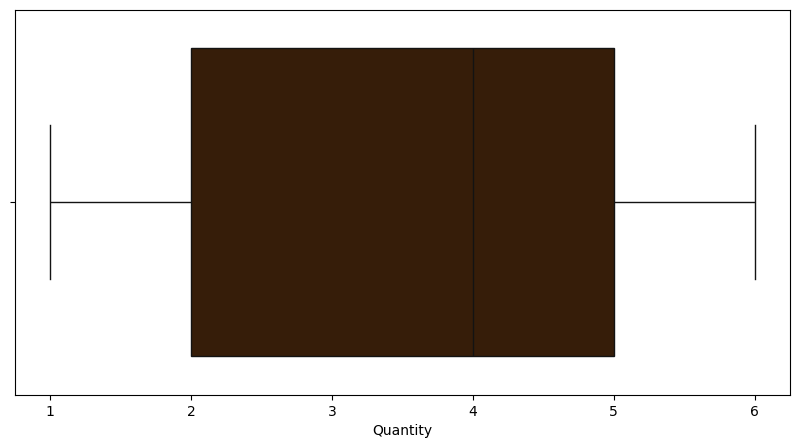

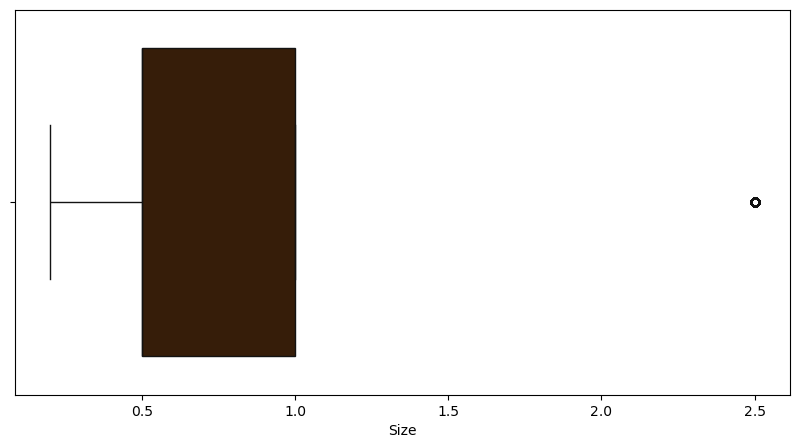

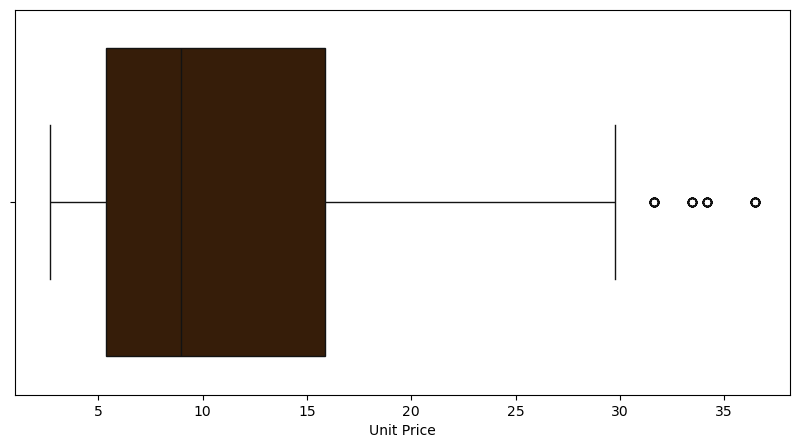

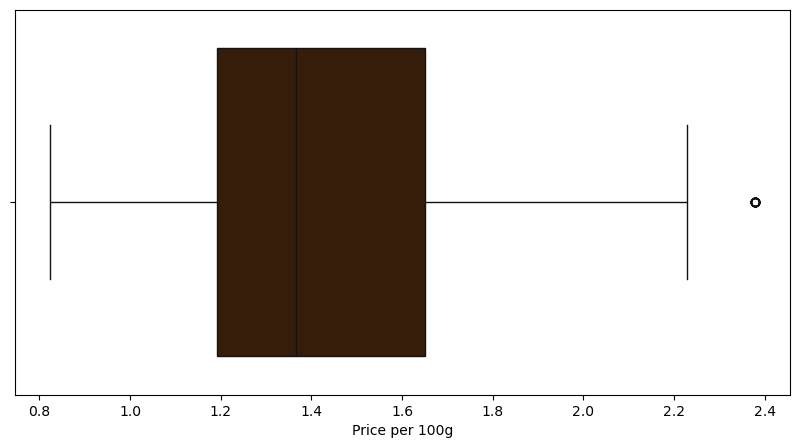

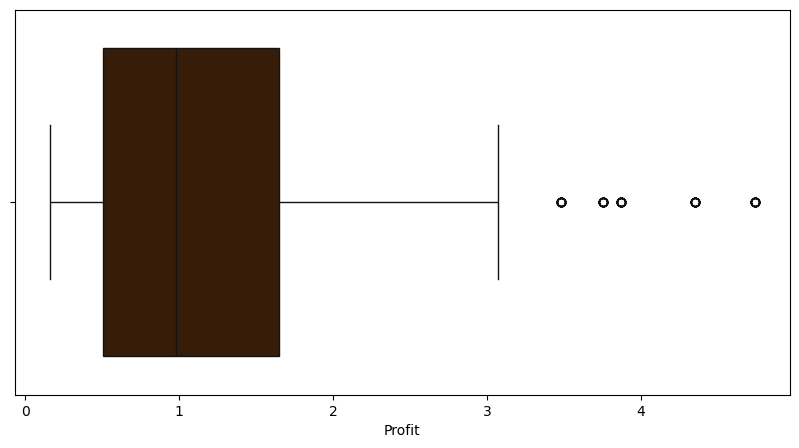

In [28]:
for col in df.select_dtypes(include='number').columns:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=df[col], color='#3D1C02')
    plt.show()

In [29]:

df[(df['Size'] > 2) & (df['Unit Price'] > 30) & (df['Profit'] > 3)]

,Order ID,Order Date,Customer ID,Product ID,Quantity,Customer Name,Email,Phone Number,Address Line 1,City,Country,Postcode,Loyalty Card,Coffee Type,Roast Type,Size,Unit Price,Price per 100g,Profit
11,VQR-01002-970,2020-10-28,49315-21985-BB,E-L-2.5,5,Duky Phizackerly,dphizackerlyb@utexas.edu,+1 (408) 533-6012,28643 Bluejay Crossing,San Jose,United States,95194,Yes,Exc,L,2.5,34.155,1.3662,3.75705
43,ULR-52653-960,2021-10-04,04152-34436-IE,L-L-2.5,2,Maurie Bartol,NaN,+1 (617) 493-7594,7625 Starling Court,Boston,United States,2216,No,Lib,L,2.5,36.455,1.4582,4.73915
46,DJH-05202-380,2019-11-07,85589-17020-CX,E-M-2.5,2,Donna Baskeyfied,NaN,+1 (205) 923-1460,7586 Logan Avenue,Birmingham,United States,35205,Yes,Exc,M,2.5,31.625,1.2650,3.47875
51,DWZ-69106-473,2019-05-15,76447-50326-IC,L-L-2.5,4,Karry Flanders,kflanders1f@over-blog.com,+353 (467) 720-7274,88 Blue Bill Park Avenue,Crumlin,Ireland,D6W,Yes,Lib,L,2.5,36.455,1.4582,4.73915
53,YHV-68700-050,2019-09-11,26333-67911-OL,L-L-2.5,2,Hartley Mattioli,hmattioli1g@webmd.com,NaN,126 Valley Edge Street,Kinloch,United Kingdom,PH43,No,Lib,L,2.5,36.455,1.4582,4.73915
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
928,FBZ-64200-586,2022-07-12,51738-61457-RS,E-M-2.5,2,Mathilda Matiasek,mmatiasekps@ucoz.ru,NaN,30867 Magdeline Way,New York City,United States,10004,Yes,Exc,M,2.5,31.625,1.2650,3.47875
955,NCH-55389-562,2019-04-27,86579-92122-OC,E-L-2.5,5,Brenn Dundredge,NaN,+1 (405) 369-5173,5 Morrow Street,Oklahoma City,United States,73129,Yes,Exc,L,2.5,34.155,1.3662,3.75705
984,WVV-79948-067,2021-01-18,66070-30559-WI,E-M-2.5,1,Ramon Cheak,rcheakrc@tripadvisor.com,NaN,23 Paget Point,Bundoran,Ireland,F94,Yes,Exc,M,2.5,31.625,1.2650,3.47875
986,GCD-75444-320,2020-05-04,51277-93873-RP,L-M-2.5,1,Claudell Ayre,cayrere@symantec.com,+1 (386) 573-2575,5645 Lotheville Crossing,Daytona Beach,United States,32128,No,Lib,M,2.5,33.465,1.3386,4.35045


**1**- 2 Columns have nulls:

    - Email Null Percentage: 20.6%

    - Phone Number Null Percentage: 13.5%


**Proposed Strategy** --> replacing nulls with 'Missing'


**2-** 1 Column has mixed capitalization:

    - Postcode 
    

**Proposed Strategy**--> .upper() the whole column

**3-** 4 Columns have outliers:
    - Size
    - Unit Price
    - Price per 100g
    - Profit
    --> at the first glance you  may think those are outliers but after exploring the data, we found that the outliers in the price comes with the outlier in size so it is reasonable. larger the size, larger the price


**Data Cleaning**

In [30]:
df['Email'] = df['Email'].fillna('Missing')
df['Phone Number'] = df['Phone Number'].fillna('Missing')

In [31]:
df.isna().sum()

Order ID          0
Order Date        0
Customer ID       0
Product ID        0
Quantity          0
Customer Name     0
Email             0
Phone Number      0
Address Line 1    0
City              0
Country           0
Postcode          0
Loyalty Card      0
Coffee Type       0
Roast Type        0
Size              0
Unit Price        0
Price per 100g    0
Profit            0
dtype: int64

In [32]:
df['Postcode'] = df['Postcode'].astype(str).str.upper()

**WE CHOSED TO FILL THE NULLS IN EMAIL AND PHONE COLUMNS WITH MISSING AS IT WONT AFFECT OUR ANALYSIS THAT MUCH
AND IF WE DROPPED THEM WE WILL LOSE SOME DATA WHICH THE ANALYSIS PHASE MAINLY RELY ON**


**WE UNIFIED THE POSTCODE COLUMN TO BE IN UPPER CASE FORM**

In [33]:
df['Month'] = df['Order Date'].dt.month_name()
df['Month']

0      September
1      September
2           June
3           July
4           July
         ...    
995      January
996          May
997      October
998       August
999      October
Name: Month, Length: 1000, dtype: object

In [34]:
df['Year'] = df['Order Date'].dt.year
df['Year']

0      2019
1      2019
2      2021
3      2021
4      2021
       ... 
995    2020
996    2022
997    2019
998    2021
999    2020
Name: Year, Length: 1000, dtype: int32

In [35]:
df['Day'] = df['Order Date'].dt.day_name()
df['Day']

0       Thursday
1       Thursday
2       Thursday
3       Thursday
4       Thursday
         ...    
995       Monday
996    Wednesday
997       Friday
998      Tuesday
999     Thursday
Name: Day, Length: 1000, dtype: object

In [36]:
df['Cost'] = df['Unit Price'] - df['Profit']
df['Cost'].nunique()
#cost of each product

48

In [37]:
df['Profit Margin %'] = (df['Profit'] / df['Unit Price']) *100
df['Profit Margin %']
#profit margin for each product

0       6.0
1      11.0
2       9.0
3      11.0
4       6.0
       ... 
995     6.0
996     6.0
997     9.0
998     9.0
999    11.0
Name: Profit Margin %, Length: 1000, dtype: float64

In [39]:
df['Total Profit'] = df['Profit'] * df['Quantity']
df['Total Profit']

0      1.19400
1      4.53750
2      1.16550
3      3.02500
4      3.29820
        ...   
995    1.64910
996    1.79100
997    2.43000
998    0.89550
999    1.36125
Name: Total Profit, Length: 1000, dtype: float64

In [38]:
df['Total Sales'] = df['Unit Price'] * df['Quantity']
df['Total Sales']

0      19.900
1      41.250
2      12.950
3      27.500
4      54.970
        ...  
995    27.485
996    29.850
997    27.000
998     9.950
999    12.375
Name: Total Sales, Length: 1000, dtype: float64

In [40]:
def categorize_size(size):
    if size <= 0.2: return 'Small'
    elif size <= 0.5: return 'Medium'
    else: return 'Large'

df['Size Category'] = df['Size'].apply(categorize_size)

In [41]:
df.columns

Index(['Order ID', 'Order Date', 'Customer ID', 'Product ID', 'Quantity',
       'Customer Name', 'Email', 'Phone Number', 'Address Line 1', 'City',
       'Country', 'Postcode', 'Loyalty Card', 'Coffee Type', 'Roast Type',
       'Size', 'Unit Price', 'Price per 100g', 'Profit', 'Month', 'Year',
       'Day', 'Cost', 'Profit Margin %', 'Total Sales', 'Total Profit',
       'Size Category'],
      dtype='object')

In [42]:
df.to_csv('Cleaned_Coffee_Beans.csv', index=False)

**Exploratory Data Analysis**

**SALES PERFORMANCE**

In [43]:
# What is the total revenue across the entire time period?
total_revenue=df["Total Sales"].sum()
total_revenue

np.float64(45134.255)

In [44]:
# How has revenue evolved over the years?
yearly_revenue = df.groupby(df["Order Date"].dt.year)["Total Sales"].sum()
yearly_revenue
#it decreased in 2022 

Order Date
2019    12187.165
2020    12117.545
2021    13766.110
2022     7063.435
Name: Total Sales, dtype: float64

In [45]:
# Which months and quarters generate the highest sales?
monthly_sales = df.groupby('Month')['Total Sales'].sum().sort_values(ascending=False)
print("Highest Sales by Month:")
print(monthly_sales)

Highest Sales by Month:
Month
June         4843.040
March        4795.775
April        4224.595
February     4138.205
July         3982.915
October      3800.075
September    3633.645
November     3548.430
January      3503.035
May          3247.980
December     3089.660
August       2326.900
Name: Total Sales, dtype: float64


In [46]:
df['Quarter'] = df['Order Date'].dt.to_period('Q')
quarterly_sales = df.groupby('Quarter')['Total Sales'].sum().sort_values(ascending=False)

print("\nHighest Sales by Quarter:")
print(quarterly_sales)
#Q1,Q4 always have the best profits


Highest Sales by Quarter:
Quarter
2021Q4    4164.560
2021Q3    3482.590
2019Q2    3463.995
2020Q4    3375.465
2021Q1    3341.155
2020Q1    3280.080
2020Q2    3139.605
2019Q3    2987.500
2022Q1    2978.250
2022Q2    2934.210
2019Q4    2898.140
2019Q1    2837.530
2021Q2    2777.805
2020Q3    2322.395
2022Q3    1150.975
Freq: Q-DEC, Name: Total Sales, dtype: float64


**PRODUCT ANALYSIS**

In [47]:
# Which coffee types generate the most revenue?
coffee_revenue = df.groupby("Coffee Type")["Total Sales"].sum().reset_index()
coffee_revenue = coffee_revenue.sort_values("Total Sales", ascending=False)
coffee_revenue
#Exc

,Coffee Type,Total Sales
1,Exc,12306.440
2,Lib,12054.075
0,Ara,11768.495
3,Rob,9005.245


In [48]:
# Which coffee types sell in the largest quantities?
coffee_qty = df.groupby("Coffee Type")["Quantity"].sum().reset_index()
coffee_qty = coffee_qty.sort_values("Quantity", ascending=False)
coffee_qty
#Ara

,Coffee Type,Quantity
0,Ara,947
3,Rob,878
1,Exc,872
2,Lib,854


In [49]:
# How does the roast type affect sales performance?
roast_profit = df.groupby("Roast Type")["Total Sales"].sum().reset_index()
roast_profit = roast_profit.sort_values("Total Sales", ascending=False)
roast_profit
#Light Roast has the largest sales performance

,Roast Type,Total Sales
1,L,17354.465
2,M,14600.475
0,D,13179.315


In [50]:
#Which product sizes are most popular?
size_popularity = df.groupby("Size")["Quantity"].sum().reset_index()
size_popularity = size_popularity.sort_values("Quantity", ascending=False)
size_popularity


,Size,Quantity
1,0.5,943
0,0.2,892
2,1.0,875
3,2.5,841


In [51]:
# Is there a relationship between price and sales volume?
correlation = df['Unit Price'].corr(df['Quantity'])
print(f"Correlation between Price and Sales Volume: {correlation:.2f}")  
#Negative Corr

Correlation between Price and Sales Volume: -0.04


In [52]:
# Which products have the highest profit margins, and are they the best-sellers?
best_sellers = df.groupby("Product ID")["Profit Margin %"].sum().reset_index()
best_sellers = best_sellers.sort_values("Profit Margin %", ascending=False)
best_sellers.head(10)
#L-D-0.5

,Product ID,Profit Margin %
25,L-D-0.5,338.0
28,L-L-0.2,325.0
32,L-M-0.2,312.0
27,L-D-2.5,299.0
29,L-L-0.5,273.0
30,L-L-1,273.0
9,A-M-0.5,270.0
13,E-D-0.5,264.0
26,L-D-1,260.0
31,L-L-2.5,260.0


**CUSTOMER ANALYSIS**

In [53]:
# How many unique customers are there?
df["Customer ID"].nunique()
#913

913

In [54]:
# Which countries and cities contribute the most to sales?
country_sales = df.groupby("Country")["Total Sales"].sum().reset_index()
country_sales = country_sales.sort_values("Total Sales", ascending=False)
country_sales
#US


,Country,Total Sales
2,United States,35638.885
0,Ireland,6696.865
1,United Kingdom,2798.505


In [55]:
# What percentage of customers have a loyalty card?
loyalty_rate = (df['Loyalty Card'] == 'Yes').mean() * 100
print(f"Percentage of loyalty card holders: {loyalty_rate:.2f}%")

Percentage of loyalty card holders: 47.90%


In [56]:
# Do loyalty card holders spend more than non-loyalty customers? 
loyality_spend = df.groupby('Loyalty Card')['Total Sales'].sum()
loyality_spend
#NO, non loyalty spends more

Loyalty Card
No     24216.405
Yes    20917.850
Name: Total Sales, dtype: float64

In [57]:
# Who are the top 10 customers by total spending?
top_10_customers = df.groupby('Customer Name')['Total Sales'].sum().nlargest(10)
top_10_customers

Customer Name
Allis Wilmore      317.070
Brenn Dundredge    307.045
Terri Farra        289.110
Nealson Cuttler    281.675
Don Flintiff       278.010
Derick Snow        251.125
Brice Romera       246.210
Alexa Sizey        218.730
Ailey Brash        206.600
Daniel Heinonen    204.930
Name: Total Sales, dtype: float64

In [58]:
# What is the average order value per customer segment?
segment_analysis = df.groupby('Loyalty Card').agg({ 'Total Sales': 'sum','Order ID': 'nunique'})
segment_analysis['Average Order Value'] = segment_analysis['Total Sales'] / segment_analysis['Order ID']
print(segment_analysis[['Average Order Value']])

              Average Order Value
Loyalty Card                     
No                      49.120497
Yes                     45.081573


In [59]:
# How many customers made only a single purchase?
customer_orders = df.groupby('Customer ID')['Order ID'].nunique()
single_purchase_customers = (customer_orders == 1).sum()
print(single_purchase_customers)

888


**Time-Based & Statistical Analysis**

In [60]:
# How does sales performance differ across days of the week? 
daily_sales = df.groupby('Day')['Total Sales'].sum()
daily_sales


Day
Friday       7305.735
Monday       5968.290
Saturday     6202.720
Sunday       7156.375
Thursday     6541.065
Tuesday      5582.970
Wednesday    6377.100
Name: Total Sales, dtype: float64

In [61]:
# What are the descriptive statistics (mean, median, std) for key metrics?
key_metrics = ['Total Sales', 'Total Profit', 'Quantity', 'Unit Price']
stats = df[key_metrics].describe()
stats.loc['median'] = df[key_metrics].median()
print(stats.loc[['mean', 'median', 'std']])

        Total Sales  Total Profit  Quantity  Unit Price
mean      45.134255      4.520217  3.551000   12.908080
median    29.785000      2.904150  4.000000    8.950000
std       42.220454      4.647257  1.681733    9.772455


In [62]:
# What is the distribution of order values — is it normal or skewed?
mean_val = df['Total Sales'].mean()
median_val = df['Total Sales'].median()
skewness = df['Total Sales'].skew()
print(f"Mean: {mean_val:.2f}")
print(f"Median: {median_val:.2f}")
print(f"Skewness: {skewness:.2f}")
#right skewed

Mean: 45.13
Median: 29.78
Skewness: 1.65


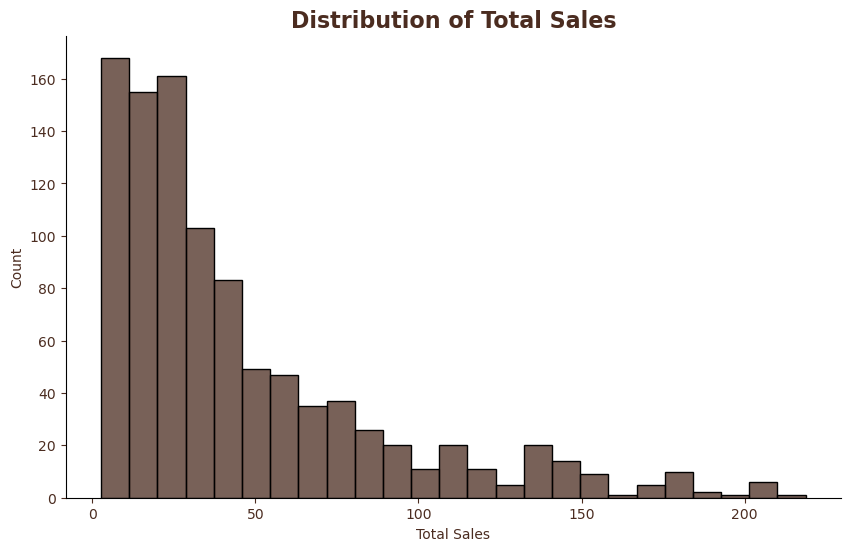

In [63]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df["Total Sales"], color='#4b2c20')
plt.title('Distribution of Total Sales', fontsize=16, fontweight='bold', color='#4b2c20')
plt.xlabel('Total Sales', color='#4b2c20')
plt.ylabel('Count', color='#4b2c20')

ax.tick_params(axis='x', colors='#4b2c20')
ax.tick_params(axis='y', colors='#4b2c20')
sns.despine()
plt.show()

**DATA VISUALIZATION**

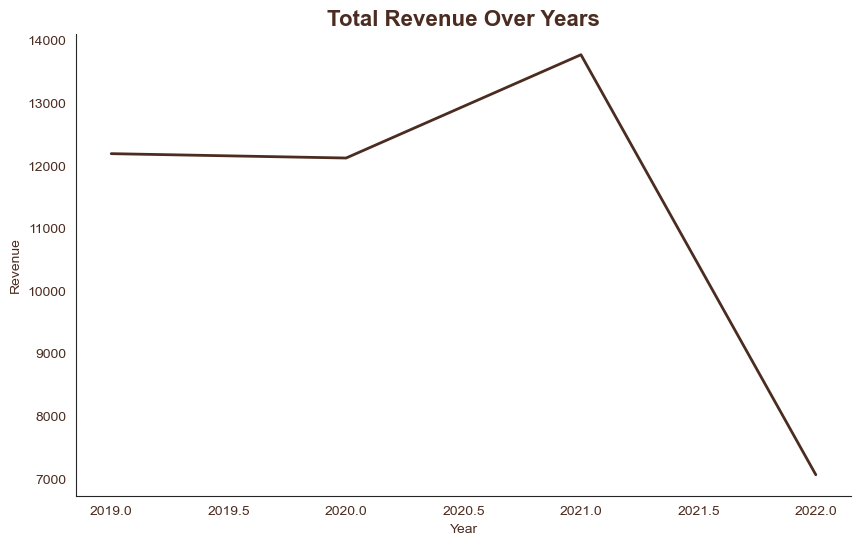

In [81]:
#A time-series chart showing revenue over the full period(OVER YEARS)
fig, ax = plt.subplots(figsize=(10,6))
sns.lineplot(data=df, x='Year', y='Total Sales', color='#4b2c20', linewidth=2, estimator='sum', errorbar=None)
plt.title('Total Revenue Over Years', fontsize=16, fontweight='bold', color='#4b2c20')
plt.xlabel('Year', color='#4b2c20')
plt.ylabel('Revenue', color='#4b2c20')

ax.tick_params(axis='x', colors='#4b2c20')
ax.tick_params(axis='y', colors='#4b2c20')
sns.despine()
plt.show()


**Early 2021 was peak revenue but it suddenly decreased till it dropped to its lowest revenue in 2022**

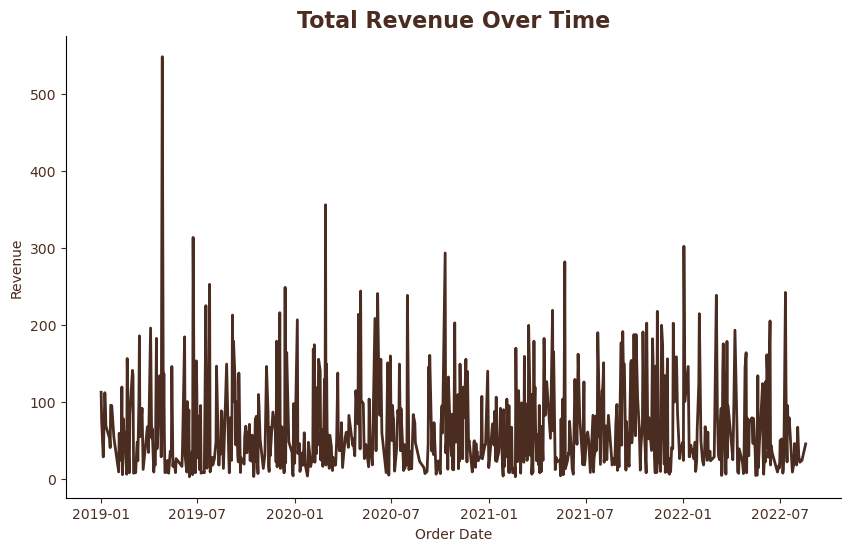

In [64]:
#A time-series chart showing revenue over the full period
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df, x='Order Date', y='Total Sales', color='#4b2c20', linewidth=2, estimator='sum', errorbar=None)
plt.title('Total Revenue Over Time', fontsize=16, fontweight='bold', color='#4b2c20')
plt.xlabel('Order Date', color='#4b2c20')
plt.ylabel('Revenue', color='#4b2c20')

ax.tick_params(axis='x', colors='#4b2c20')
ax.tick_params(axis='y', colors='#4b2c20')
sns.despine()
plt.show()

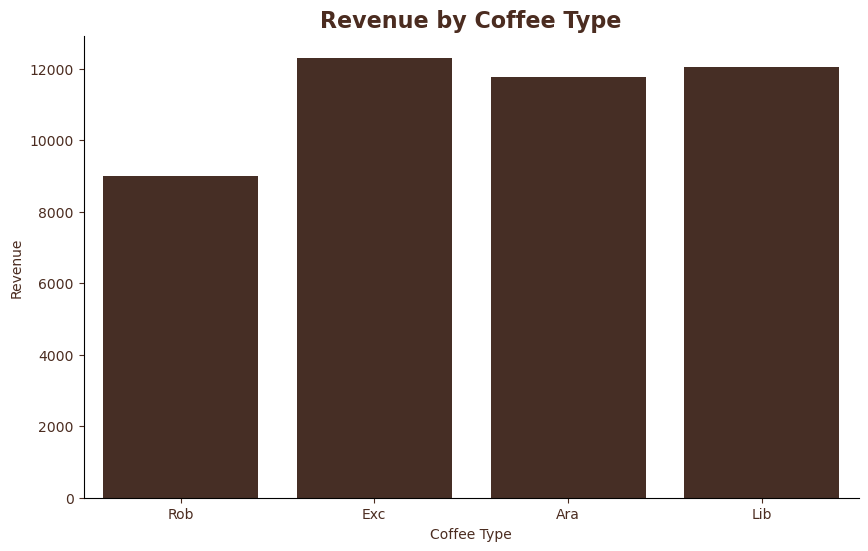

In [65]:
#2. A comparison chart across coffee categories 
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(data=df, x='Coffee Type', y='Total Sales', color='#4b2c20', linewidth=2, estimator='sum', errorbar=None)
plt.title('Revenue by Coffee Type', fontsize=16, fontweight='bold', color='#4b2c20')
plt.xlabel('Coffee Type', color='#4b2c20')
plt.ylabel('Revenue', color='#4b2c20')

ax.tick_params(axis='x', colors='#4b2c20')
ax.tick_params(axis='y', colors='#4b2c20')
sns.despine() 
plt.show()

**EXC COFFEE TYPE HAS MOST REVENUE**


In [83]:
#3. A chart showing geographic distribution of sales 
geo_data = df.groupby('Country')['Total Sales'].sum().reset_index()

fig = px.choropleth(data_frame=geo_data, locations='Country', locationmode='country names', color='Total Sales', 
                    hover_name='Country', title='Geographic distribution of Sales' ,color_continuous_scale='YlOrBr') 
fig.show()
fig.write_html("Geographic distribution of Sales.html")

**US HAS MORE SALES THAN IRELAND WHICH HAS MORE SALES THAN UK**

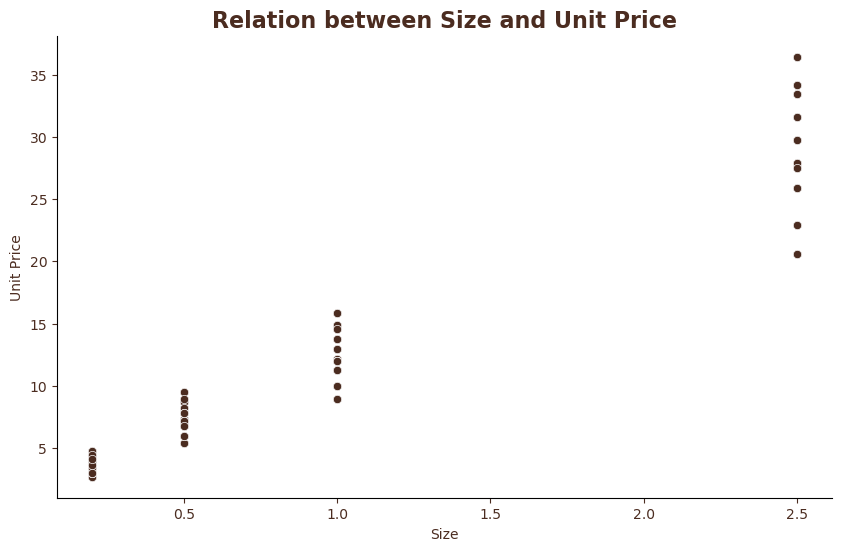

In [67]:
#4. A chart examining the relationship between two numeric variables 
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(data=df, x='Size', y='Unit Price', color='#4b2c20')
plt.title('Relation between Size and Unit Price', fontsize=16, color='#4b2c20', fontweight='bold')
plt.xlabel('Size', color='#4b2c20')
plt.ylabel('Unit Price', color='#4b2c20')

ax.tick_params(axis='x', colors='#4b2c20')
ax.tick_params(axis='y', colors='#4b2c20')
sns.despine() 
plt.show()

**THERE IS CORRELATION BETWEEN SIZE & UNIT PRICE, IT DOESNT SHOW PROPERLY BECAUSE THE SIZE HAS TOO FEW UNIQUE DATA POINTS**

In [68]:
correlation = df[['Size', 'Unit Price']].corr()
print(correlation)

                Size  Unit Price
Size        1.000000    0.964381
Unit Price  0.964381    1.000000


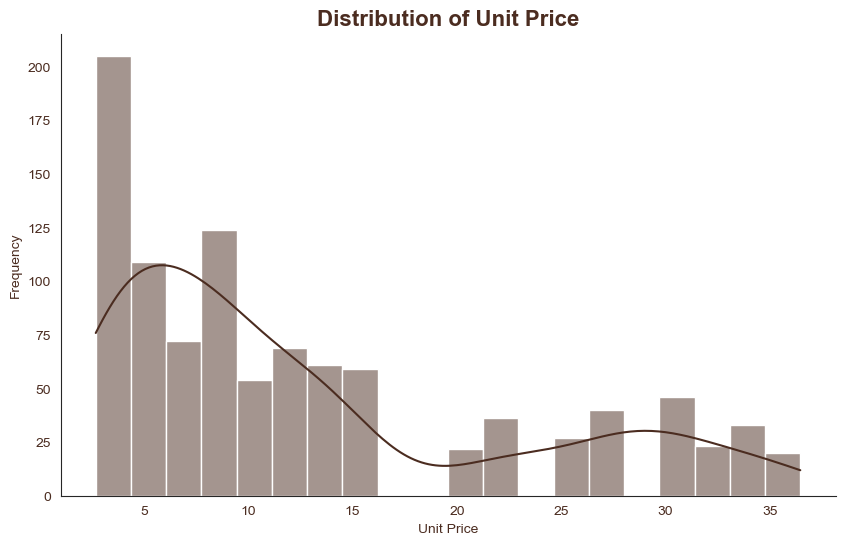

In [87]:
##5. A chart showing the distribution of a continuous variable 
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(data=df, x='Unit Price', kde=True, 
             color='#4b2c20', bins=20, ax=ax)

ax.tick_params(axis='x', colors='#4b2c20')
ax.tick_params(axis='y', colors='#4b2c20')

plt.title('Distribution of Unit Price', color='#4b2c20', fontsize=16, fontweight='bold')
plt.xlabel('Unit Price', color='#4b2c20')
plt.ylabel('Frequency', color='#4b2c20')

sns.despine() 
plt.show()

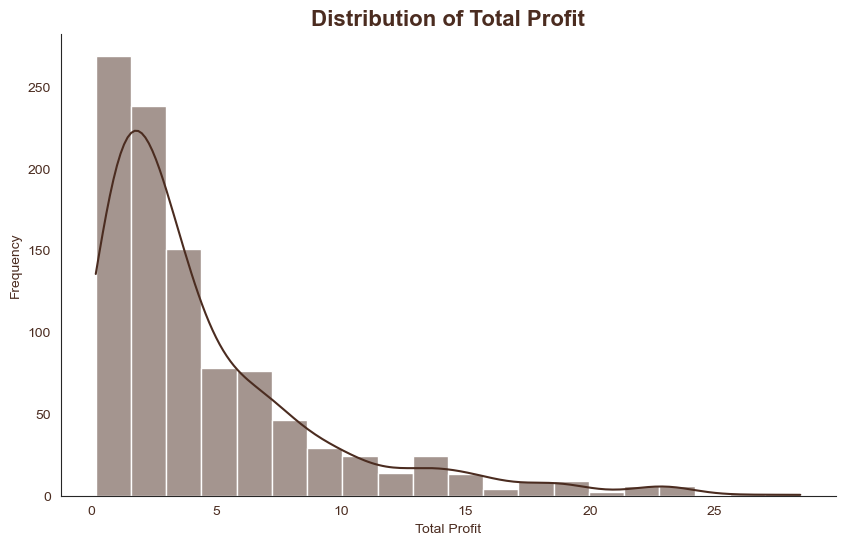

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(data=df, x='Total Profit', kde=True, 
             color='#4b2c20', bins=20, ax=ax)

ax.tick_params(axis='x', colors='#4b2c20')
ax.tick_params(axis='y', colors='#4b2c20')

plt.title('Distribution of Total Profit', color='#4b2c20', fontsize=16, fontweight='bold')
plt.xlabel('Total Profit', color='#4b2c20')
plt.ylabel('Frequency', color='#4b2c20')

sns.despine() 
plt.show()
#Total Profit is right skewed

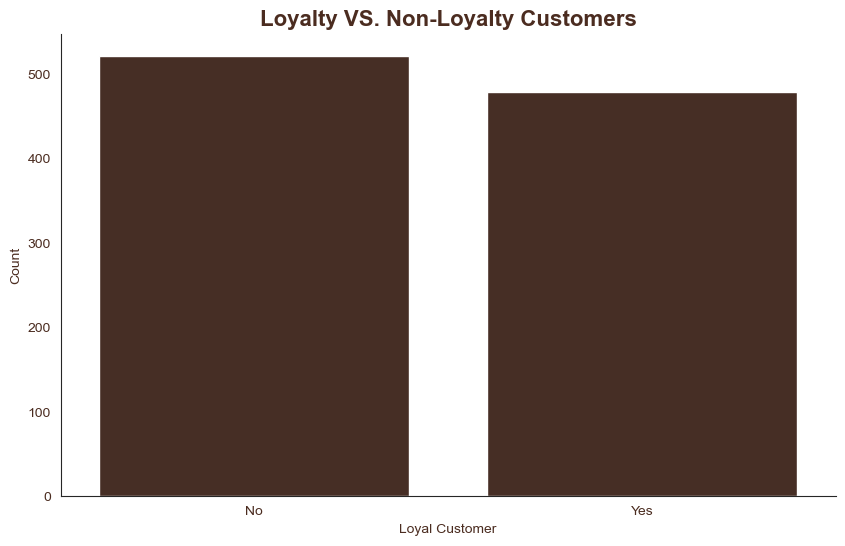

In [88]:
#6. A chart comparing loyalty vs. non-loyalty customers 
loyalty_counts = df['Loyalty Card'].value_counts()
fig, ax= plt.subplots(figsize=(10,6))
sns.barplot(x=loyalty_counts.index, y=loyalty_counts, color='#4b2c20')
ax.tick_params(axis='x', colors='#4b2c20')
ax.tick_params(axis='y', colors='#4b2c20')

plt.title('Loyalty VS. Non-Loyalty Customers', color='#4b2c20', fontsize=16, fontweight='bold')
plt.xlabel('Loyal Customer', color='#4b2c20')
plt.ylabel('Count', color='#4b2c20')

sns.despine() 
plt.show()

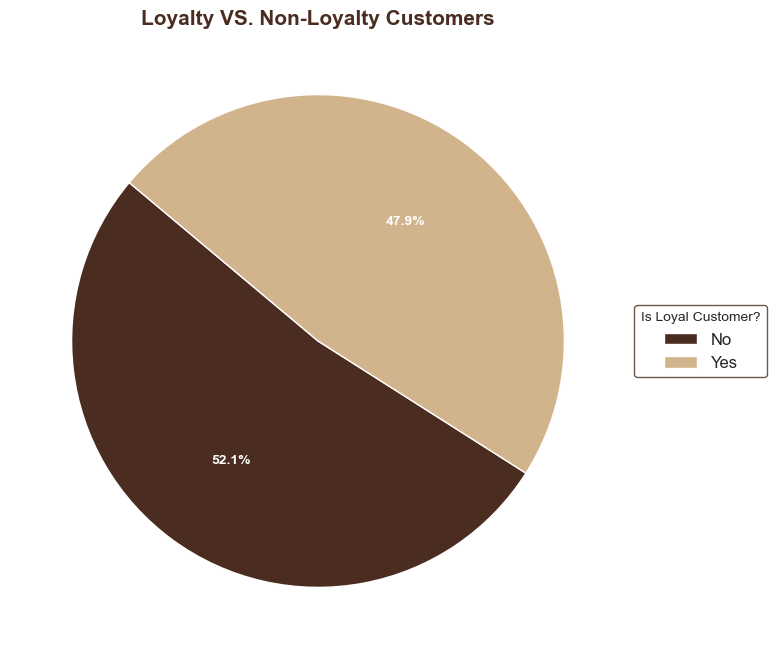

In [89]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(8, 8))

colors = ['#4b2c20', '#d2b48c']
wedges, texts, autotexts = ax.pie(loyalty_counts, labels=None, autopct='%1.1f%%', startangle=140, 
                                  colors=colors, textprops={'color':"w", 'weight':'bold'}) 

ax.legend(wedges, loyalty_counts.index, title="Is Loyal Customer?", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), 
          fontsize=12, frameon=True, facecolor='white', edgecolor='#4b2c20')      

ax.set_title('Loyalty VS. Non-Loyalty Customers', color='#4b2c20', fontsize=15, fontweight='bold')

plt.show()

**THERE IS MORE NON LOYAL CUSTOMER THAN LOYAL ONES**

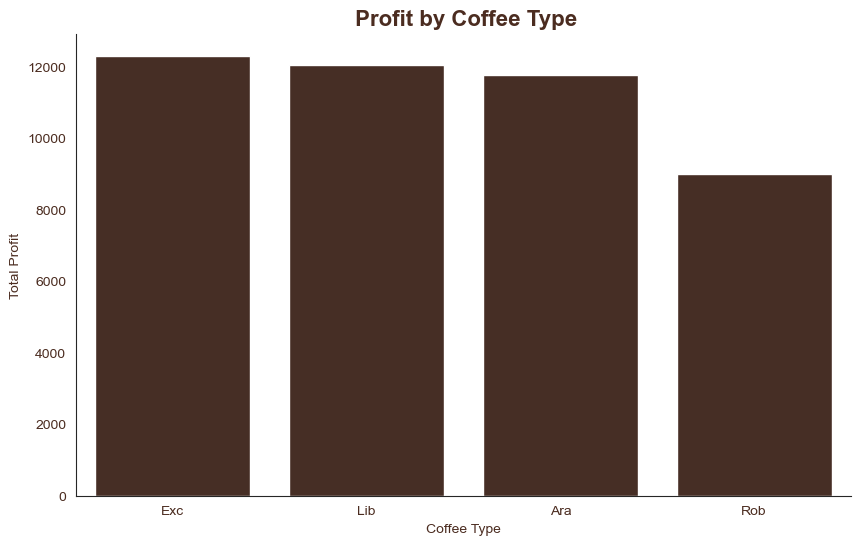

In [ ]:
#7. A chart showing the top performers in some category
top_performers = df.groupby('Coffee Type')['Total Sales'].sum().nlargest(5).reset_index()
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(data=top_performers, x='Coffee Type', y='Total Sales',  color='#4b2c20')

ax.tick_params(axis='x', colors='#4b2c20')
ax.tick_params(axis='y', colors='#4b2c20')

plt.title('Profit by Coffee Type', color='#4b2c20', fontsize=16, fontweight='bold')
plt.xlabel('Coffee Type', color='#4b2c20')
plt.ylabel('Total Profit', color='#4b2c20')

sns.despine()
plt.show()

**EXC COFFEE TYPE HAS MOST REVENUE**


In [73]:
top_performers

,Coffee Type,Total Sales
0,Exc,12306.440
1,Lib,12054.075
2,Ara,11768.495
3,Rob,9005.245


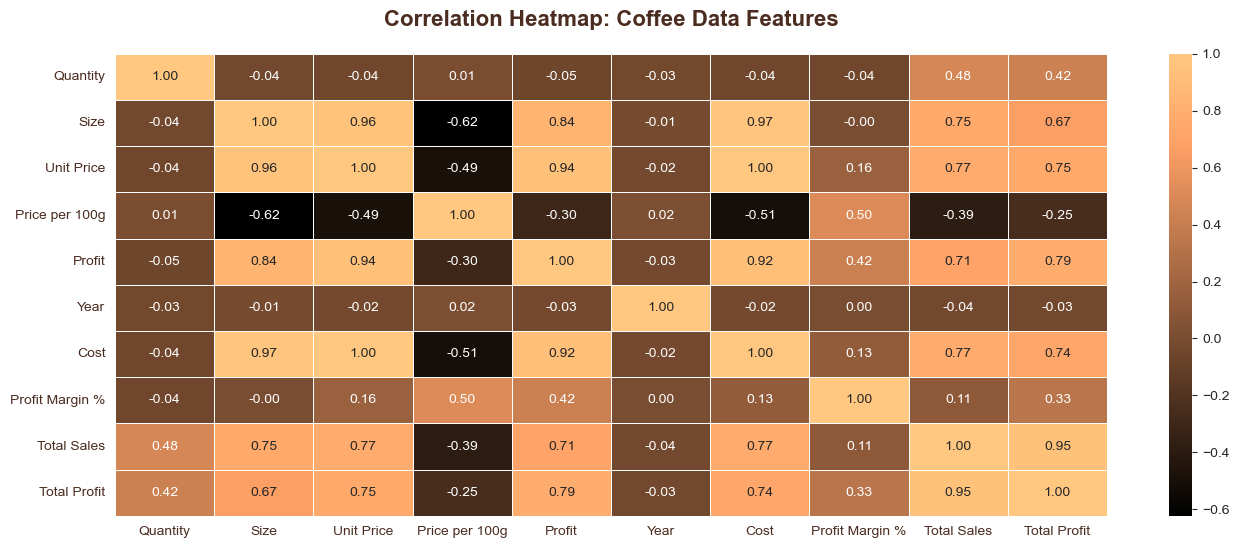

In [74]:
# A heatmap showing patterns across two dimensions
plt.figure(figsize=(16, 6))
heatmap = sns.heatmap(df.select_dtypes("number").corr(), annot=True, fmt=".2f", cmap='copper', linewidths=0.5)

plt.xticks(color='#4b2c20', fontsize=10)
plt.yticks(color='#4b2c20', fontsize=10)

plt.title('Correlation Heatmap: Coffee Data Features', fontweight='bold', color='#4b2c20', fontsize=16, pad=20)

plt.show()

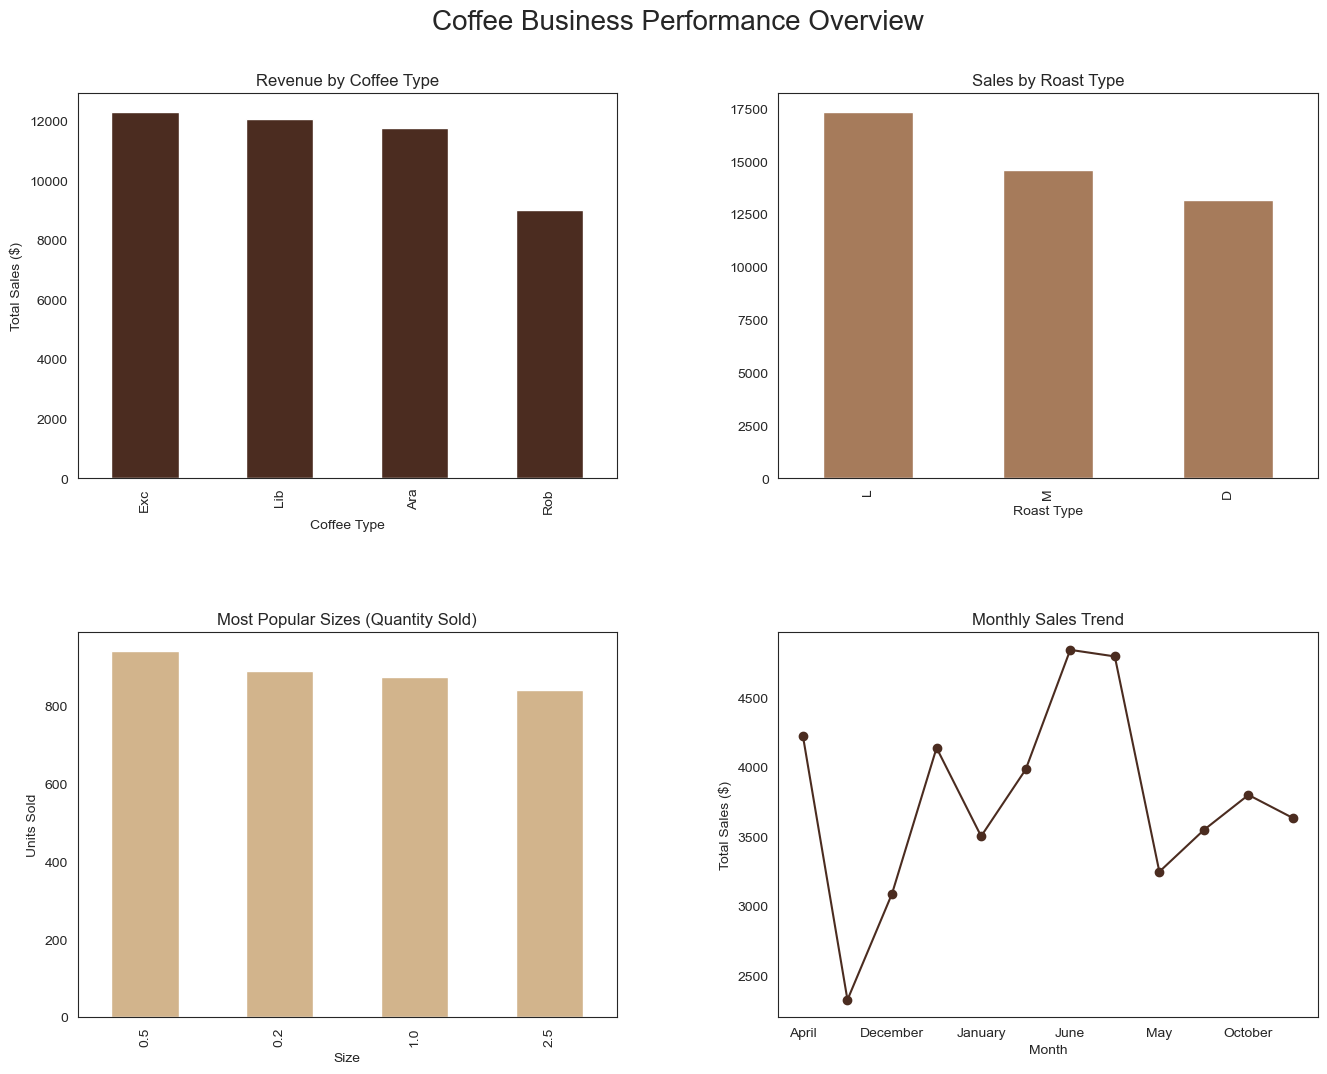

In [75]:
# A multi-chart figure with subplots combining related views
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

coffee_rev = df.groupby('Coffee Type')['Total Sales'].sum().sort_values(ascending=False)
coffee_rev.plot(kind='bar', ax=axes[0, 0], color='#4b2c20')
axes[0, 0].set_title('Revenue by Coffee Type')
axes[0, 0].set_ylabel('Total Sales ($)')
roast_perf = df.groupby('Roast Type')['Total Sales'].sum().sort_values(ascending=False)
roast_perf.plot(kind='bar', ax=axes[0, 1], color='#A67B5B')
axes[0, 1].set_title('Sales by Roast Type')


size_pop = df.groupby('Size')['Quantity'].sum().sort_values(ascending=False)
size_pop.plot(kind='bar', ax=axes[1, 0], color='#d2b48c')
axes[1, 0].set_title('Most Popular Sizes (Quantity Sold)')
axes[1, 0].set_ylabel('Units Sold')


monthly_trend = df.groupby('Month')['Total Sales'].sum()
monthly_trend.plot(kind='line', ax=axes[1, 1], marker='o', color='#4b2c20')
axes[1, 1].set_title('Monthly Sales Trend')
axes[1, 1].set_ylabel('Total Sales ($)')

plt.suptitle('Coffee Business Performance Overview', fontsize=20, y=0.95)

plt.savefig('coffee_performance_dashboard.png')
plt.show()

**EXC COFFEE TYPE HAS MOST REVENUE**

**LIGHT ROAST TYPE HAS MOST REVENUE**

**MOST POP SIZE IS 0.5**

**JUNE & MAY HAVE MOST REVENUE**


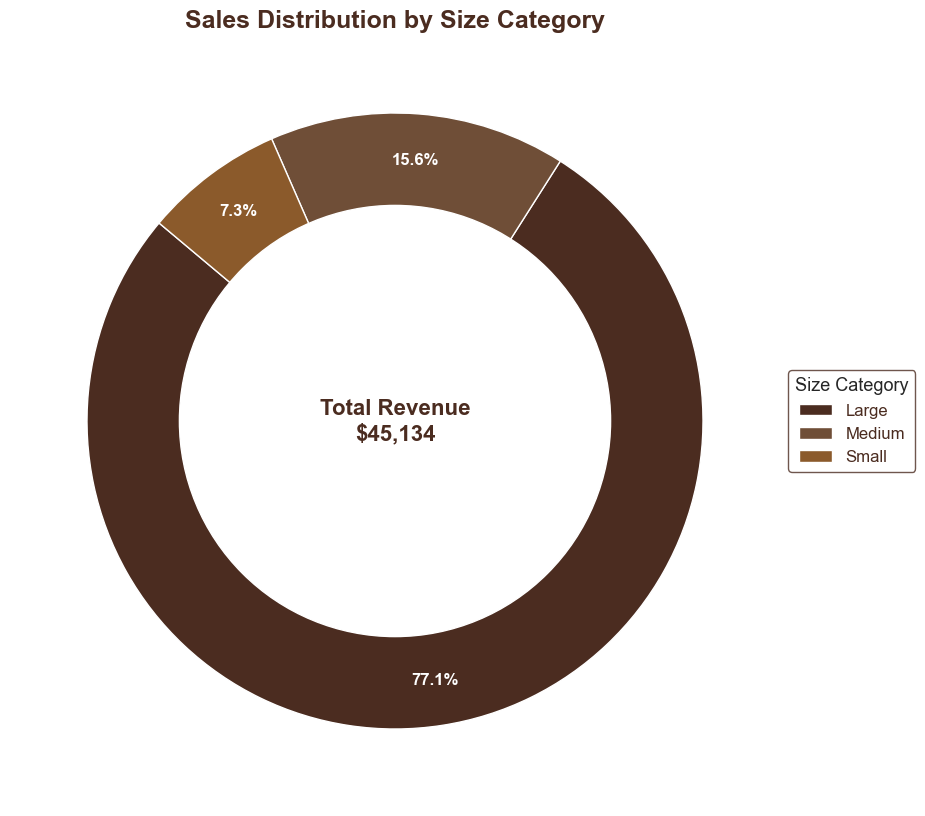

In [77]:
#
fig, ax = plt.subplots(figsize=(10, 10))
size_sales = df.groupby('Size Category')['Total Sales'].sum().sort_values(ascending=False)
colors = ['#4b2c20', '#6f4e37', '#8b5a2b', '#d2b48c', '#eed9c4']

wedges, texts, autotexts = ax.pie(size_sales, autopct='%1.1f%%', startangle=140, colors=colors,
                                  pctdistance=0.85, textprops={'fontsize': 12, 'color': 'white', 'weight': 'bold'})

centre_circle = plt.Circle((0,0), 0.7, fc='white')
fig.gca().add_artist(centre_circle)

ax.legend(wedges, size_sales.index, title="Size Category", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=12,
          title_fontsize=13, frameon=True, facecolor='white', edgecolor='#4b2c20', labelcolor='#4b2c20')    


total_revenue = size_sales.sum()
ax.text(0, 0, f'Total Revenue\n${total_revenue:,.0f}', 
        ha='center', va='center', fontsize=16, color='#4b2c20', fontweight='bold')

plt.title('Sales Distribution by Size Category', color='#4b2c20', fontsize=18, fontweight='bold')
plt.show()

**LARGE SIZE CATEGORY HAS MOST TOTAL REVENUE 77.1%**

**REPORT**

#  Coffee Sales Analysis: Executive Report

## 1. Executive Summary
* **Market Focus:** Sales are in **US, UK, and Ireland**
* **Loyalty Program:** best customers. They surprisingly doesn’t pay more and The Non Loyal pay more and provide steady profit.
* **Consistent Pricing:** A near-perfect correlation (**0.96**) exists between **Size Category** and **Unit Price**, ensuring pricing integrity.
* **Top Performers:** The **Top 3 Coffee Types** generate the majority of total revenue.

## 2. Methodology
* **Data Integration:** Consolidated datasets from Orders, Customers, and Products into a single source of truth.
* **Data Cleaning:** Handled missing values, standardized date formats, and ensured currency consistency for accurate reporting.
* **Analysis:** Used **Python & pandas** to transform raw transactions into actionable business insights.

## 3. Findings
* **Geography:** High-performing regions identified through geospatial mapping (Choropleth).
* **Preferences:** Our **Donut Chart** reveals that **Large Sizes Category** are the most popular among regular drinkers.
* **Correlations:** The **Heatmap** confirms that all product attributes (Size, Price, Profit) are logically aligned.

## 4. Recommendations
1. **Expand Loyalty Program:** Introduce incentives to convert "Non-Loyalty" customers into "Loyalty" members.
2. **Inventory Optimization:** Prioritize stock levels for the **Top2** profit-making coffee types to avoid loss of sales.
3. **Targeted Marketing:** Increase advertising spend in high-performing cities identified in the geographic analysis.
4. **Bundle Strategy:** Create "Value Bundles" for the most popular size categories to increase the average order value.

## 5. Conclusion
The business shows strong performance with a loyal customer base. By focusing on **high-profit products** and **geographic expansion**, we can further optimize revenue and operational efficiency.